# Concatenating, Joining, and Pivoting Data

There are several ways of answering many questions in this notebook, but try to use the new operations (concatenate, joint/merge, pivot) whenever possible to get practice.

In [1]:
import pandas as pd

## Movie Ratings Data

The Movielens data set (https://dlsun.github.io/pods/data/ml-1m/ ) contains 1 million movie ratings submitted by users. The information about the movies, ratings, and users are stored in three separate files, called `movies.dat`, `ratings.dat`, and `users.dat`. The column names are not included with the data files. Refer to the webpage above for more information.


1\. Read in each of the data files.


(Hint: see the note in the documentation about the delimiter; use the `sep` argument in `read_csv`. If you get an error when reading the `movies.dat` file, try `encoding_errors = "ignore"` in `read_csv`.)

In [2]:
base = "https://dlsun.github.io/pods/data/ml-1m/"
movies = base + "movies.dat"
movies = pd.read_csv(movies, sep="::", encoding_errors="ignore", header = None, names = ["movie_id", "title", "generes"])
movies.head()

<positron-console-cell-2>:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


,movie_id,title,generes
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [3]:
ratings = base + "ratings.dat"
ratings = pd.read_csv(ratings, sep="::", encoding_errors="ignore", header = None, names = ["user_id", "movie_id", "rating", "time_stamp"])
ratings.head()

<positron-console-cell-3>:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


,user_id,movie_id,rating,time_stamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [4]:
users = base + "users.dat"
users = pd.read_csv(users, sep="::", encoding_errors="ignore", header = None, names = ["user_id","gender","age","occupation","zip-code"])
users.head()

<positron-console-cell-4>:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


,user_id,gender,age,occupation,zip-code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


2\. Which age group tends to give the highest ratings? Create an appropriate summary to answer this question.

(Note the way age is coded in the [REAMDE file](https://dlsun.github.io/pods/data/ml-1m/README.txt).)

In [5]:
rating_users = ratings.merge(users, on="user_id", how="left", validate="many_to_one")

age_label = {1:"<18", 18:"18-24", 25:"25-34", 35:"35-44", 45:"45-49", 50:"50-56", 56:"56+"}
rating_users["age_group"] = rating_users["age"].map(age_label)

rating_users.groupby("age_group")["rating"].agg(n_rating = "size", mean_rating = "mean").sort_values("mean_rating", ascending = False).reset_index()


,age_group,n_rating,mean_rating
0,56+,38780,3.766632
1,50-56,72490,3.714512
2,45-49,83633,3.638062
3,35-44,199003,3.618162
4,<18,27211,3.549520
5,25-34,395556,3.545235
6,18-24,183536,3.507573


3\. Among movies with at least 100 ratings, which movies had the highest average rating? The lowest?

In [6]:
movie_summary = (
    ratings.groupby("movie_id")["rating"]
    .agg(
        num_ratings="size",
        avg_rating="mean"
    )
    .reset_index()
)
movie_summary = movie_summary.merge(movies, on="movie_id", how="left")

top_movies = movie_summary[movie_summary["num_ratings"] >= 100]

top_movies

,movie_id,num_ratings,avg_rating,title,generes
0,1,2077,4.146846,Toy Story (1995),Animation|Children's|Comedy
1,2,701,3.201141,Jumanji (1995),Adventure|Children's|Fantasy
2,3,478,3.016736,Grumpier Old Men (1995),Comedy|Romance
3,4,170,2.729412,Waiting to Exhale (1995),Comedy|Drama
4,5,296,3.006757,Father of the Bride Part II (1995),Comedy
...,...,...,...,...,...
3690,3937,135,2.940741,Runaway (1984),Sci-Fi|Thriller
3699,3946,100,2.260000,Get Carter (2000),Action|Drama|Thriller
3701,3948,862,3.635731,Meet the Parents (2000),Comedy
3702,3949,304,4.115132,Requiem for a Dream (2000),Drama


4\. For each movie, calculate the average rating and the proportion of the ratings that were from users aged 18-24. Make a scatterplot showing the relationship between the average rating and the 18-24 share, with each point representing a movie. (Optional: Use the size of each point to represent the number of users who rated the movie.)

In [7]:
allthree = rating_users.merge(movie_summary, on="movie_id", how="left", validate="many_to_one")
movie_18 = (
    allthree.groupby(["movie_id", "title"])
    .agg(
        avg_rating=("rating", "mean"),
        num_rating=("rating", "size"),
        prop_18_24=("age", lambda x: (x == 18).mean()*100)
    )
    .reset_index()
)

movie_18.head()

,movie_id,title,avg_rating,num_rating,prop_18_24
0,1,Toy Story (1995),4.146846,2077,21.569571
1,2,Jumanji (1995),3.201141,701,21.968616
2,3,Grumpier Old Men (1995),3.016736,478,22.384937
3,4,Waiting to Exhale (1995),2.729412,170,22.941176
4,5,Father of the Bride Part II (1995),3.006757,296,21.959459


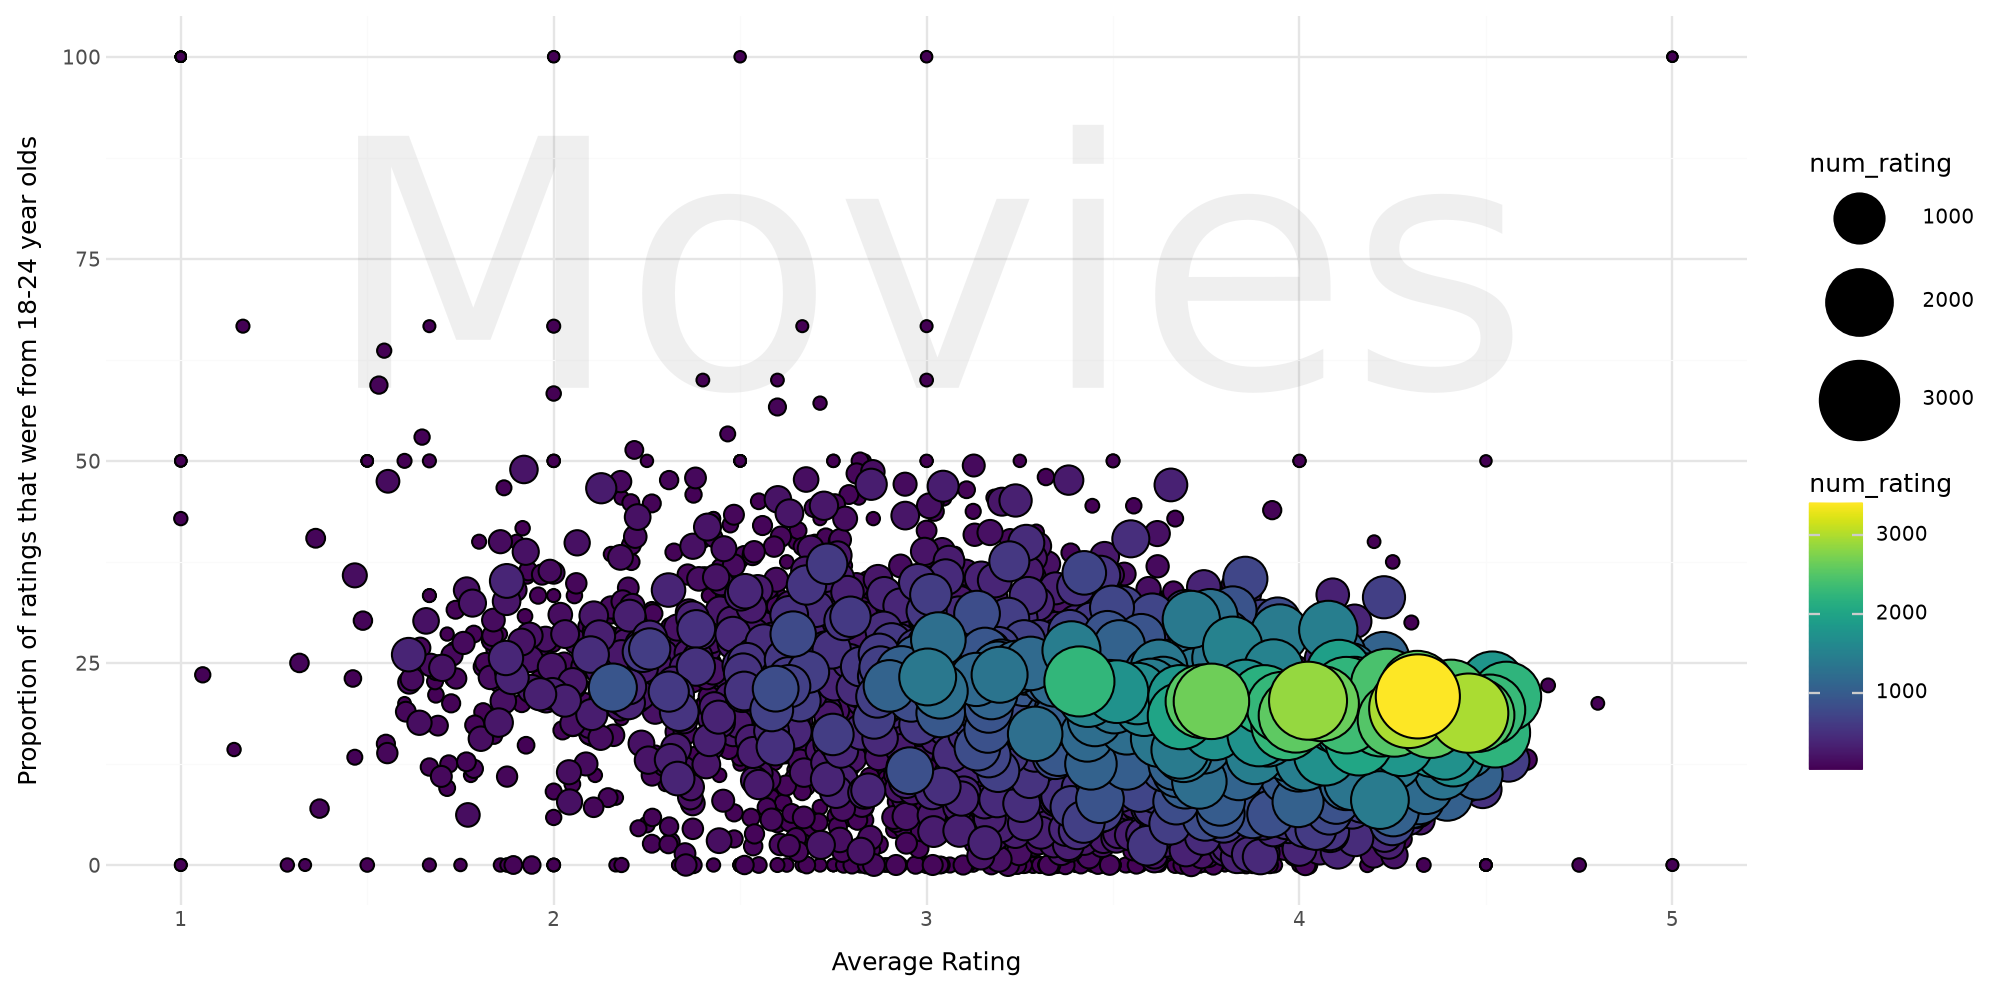

In [8]:
from plotnine import *

movie_18 = movie_18.sort_values("num_rating", ascending = True)

(
    ggplot(movie_18, aes(
        x="avg_rating",
        y="prop_18_24",
        fill="num_rating",
        size="num_rating"
    ))

    + annotate(
        "text",
        x=3,
        y=75,
        label="Movies",
        size=150,
        alpha=0.12,
        color="gray"
    )

    + geom_point(stroke=0.5, color = "black")

    + labs(
        x="Average Rating",
        y="Proportion of ratings that were from 18-24 year olds",
        size="num_rating"
    )

    + scale_size_continuous(range=(2, 20))
    + theme_minimal()
    + theme(figure_size=(12, 6))
)

5\. Calculate the number of ratings by movie. How many of the movies had zero ratings?

(_Hint_: Why is an inner join not sufficient here?)

In [9]:
rating_counts = (
    ratings.groupby("movie_id")["rating"]
    .agg(num_ratings="size")
    .reset_index()
)

movie_summary = movies.merge(
    rating_counts,
    on="movie_id",
    how="left"
)

movie_summary["num_ratings"] = (
    movie_summary["num_ratings"]
    .fillna(0)
    .astype(int)
)

movie_summary = movie_summary.sort_values(
    "num_ratings",
    ascending=True
)

(movie_summary["num_ratings"] == 0).sum()

np.int64(177)

6\. How many movies received both a 1 and a 5 rating? Which movies? How many ratings of each type (1 or 5 stars)? Answer these question by joining two appropriate tables.

In [10]:
one_star = (
    ratings[ratings["rating"] == 1]
    .groupby("movie_id")
    .size()
    .reset_index(name="num_1_star")
)

five_star = (
    ratings[ratings["rating"] == 5]
    .groupby("movie_id")
    .size()
    .reset_index(name="num_5_star")
)

one_and_five = one_star.merge(
    five_star,
    on="movie_id",
    how="inner"
)

one_and_five = one_and_five.merge(
    movies[["movie_id", "title"]],
    on="movie_id",
    how="left"
)
print("Number of movies with a one star review: ", len(one_star))
print("Number of movies with a five star review: ", len(five_star))
print("Number of movies with a one star review and a five star review: ", len(one_and_five))

one_and_five[["movie_id", "title", "num_1_star", "num_5_star"]]

Number of movies with a one star review:  3274
Number of movies with a five star review:  3232
Number of movies with a one star review and a five star review:  2986


,movie_id,title,num_1_star,num_5_star
0,1,Toy Story (1995),16,820
1,2,Jumanji (1995),42,48
2,3,Grumpier Old Men (1995),44,43
3,4,Waiting to Exhale (1995),21,6
4,5,Father of the Bride Part II (1995),28,16
...,...,...,...,...
2981,3948,Meet the Parents (2000),35,163
2982,3949,Requiem for a Dream (2000),9,132
2983,3950,Tigerland (2000),2,12
2984,3951,Two Family House (2000),1,14
